In [1]:
!python --version

Python 3.12.12


In [2]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [104]:
import numpy as np
import pandas as pd
import matplotlib as plt
import scipy as sp
from sklearn.metrics import rand_score

## EDA


In [4]:
df = pd.read_csv("spiral-dataset.csv", sep="\t", header=None, names=["x", "y", "class"])
df.head()

,x,y,class
0,31.95,7.95,3
1,31.15,7.30,3
2,30.45,6.65,3
3,29.70,6.00,3
4,28.90,5.55,3


In [5]:
df["class"].unique()

array([3, 1, 2])

## 1.2.3.Generate a figure from the given dataset that resembles Figure 1.


<Axes: xlabel='x', ylabel='y'>

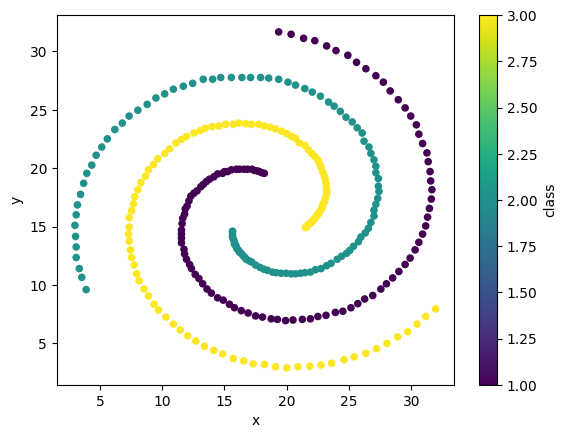

In [6]:
df.plot.scatter(x="x", y="y", c="class", colormap='viridis')

### Implement the k-means clustering algorithm. And do the following:

### • 2.a) Run your k-means algorithm on the given dataset setting the value k=3 (because visually we only have 3 clusters to worry about). And do not forget to randomly initialize the 3 centroids.


In [ ]:
# function to generate 3 random centroids within the bounds of the data
def random_centroids():
    # find the bounds of the data (doesn't need to be normalized per the instructions)
    max_x = df["x"].max()
    max_y = df["y"].max()

    # generate 3 random centroids within the bounds of the data
    centroids = [
        (np.random.rand() * max_x, np.random.rand() * max_y),
        (np.random.rand() * max_x, np.random.rand() * max_y),
        (np.random.rand() * max_x, np.random.rand() * max_y)
    ]

    # convert to a numpy array and return
    return np.array(centroids)



# function to find the closest centroid for each data point
def find_clusters(df, centroids):
    # this is going to be an array of the closest centroid for each data point
    closest_centroids = []

    # build the array of closest centroids
    for index, row in df.iterrows():
        # distances = []
        # for centroid in centroids:
        #     distance = sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)
        #     distances.append(distance)
        distances = np.array([sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)for centroid in centroids])
        cluster = np.argmin(distances)
        closest_centroids.append(cluster)
    return np.array(closest_centroids)

Now we're going to make a function to iterate:

1. Attach a kmeans_cluster value to each row
2. Use the new dataframe with the kmeans_cluster column to find the mean point for the cluster.
3. Move the centroid to the mean point of each cluster.
4. Repeat until it converges


In [ ]:
def do_kmeans(input_df):

    # make a copy of the input dataframe to work with
    kmeans_df = input_df.copy()

    # initialize the centroids and assign the initial clusters
    centroids = random_centroids()
    # print(f"Initial centroids:\n\t({centroids[0][0]:.2f}, {centroids[0][1]:.2f})\n\t({centroids[1][0]:.2f}, {centroids[1][1]:.2f})\n\t({centroids[2][0]:.2f}, {centroids[2][1]:.2f})")
    clusters = find_clusters(kmeans_df, centroids)

    # initialize some variables to prepare the preconditions for the loop
    old_centroids = [
        (0,0),
        (0,0),
        (0,0)
    ]
    kmeans_df["kmeans_cluster"] = clusters

    # loop until the centroids don't move
    while not np.array_equal(centroids, old_centroids):

        # split the dataframe into three clusters based on the kmeans_cluster column
        cluster1 = kmeans_df[kmeans_df["kmeans_cluster"] == 0]
        cluster2 = kmeans_df[kmeans_df["kmeans_cluster"] == 1]
        cluster3 = kmeans_df[kmeans_df["kmeans_cluster"] == 2]

        # store the old centroids before updating them
        old_centroids = centroids.copy()

        # update the centroids to be the mean of the points in each cluster
        centroids[0] = (cluster1["x"].mean(), cluster1["y"].mean())
        centroids[1] = (cluster2["x"].mean(), cluster2["y"].mean())
        centroids[2] = (cluster3["x"].mean(), cluster3["y"].mean())
        # if centroids[0] != old_centroids[0]:
        #     print(f"Centroid 1 moved from ({old_centroids[0][0]:.2f}, {old_centroids[0][1]:.2f}) to ({centroids[0][0]:.2f}, {centroids[0][1]:.2f})")
        # if centroids[1] != old_centroids[1]:
        #     print(f"Centroid 2 moved from ({old_centroids[1][0]:.2f}, {old_centroids[1][1]:.2f}) to ({centroids[1][0]:.2f}, {centroids[1][1]:.2f})")
        # if centroids[2] != old_centroids[2]:
        #     print(f"Centroid 3 moved from ({old_centroids[2][0]:.2f}, {old_centroids[2][1]:.2f}) to ({centroids[2][0]:.2f}, {centroids[2][1]:.2f})")

        # reassign the clusters based on the new centroids
        kmeans_df["kmeans_cluster"] = find_clusters(kmeans_df, centroids)
    
    # print(f"Final centroids:\n\t({centroids[0][0]:.2f}, {centroids[0][1]:.2f})\n\t({centroids[1][0]:.2f}, {centroids[1][1]:.2f})\n\t({centroids[2][0]:.2f}, {centroids[2][1]:.2f})")

    # we need to add 1 to the kmeans_cluster column to match the original class labels
    kmeans_df["kmeans_cluster"] = kmeans_df["kmeans_cluster"] + 1

    return kmeans_df, centroids

In [113]:
kmeans_df, centroids = do_kmeans(df)

Initial centroids:
	(31.85, 1.44)
	(9.10, 29.08)
	(6.45, 11.37)
Centroid 1 moved from (31.85, 1.44) to (26.35, 11.48)
Centroid 2 moved from (9.10, 29.08) to (18.42, 23.75)
Centroid 3 moved from (6.45, 11.37) to (13.78, 12.97)
Centroid 1 moved from (26.35, 11.48) to (25.43, 12.50)
Centroid 2 moved from (18.42, 23.75) to (18.89, 23.88)
Centroid 3 moved from (13.78, 12.97) to (11.88, 12.75)
Centroid 1 moved from (25.43, 12.50) to (25.10, 12.54)
Centroid 2 moved from (18.89, 23.88) to (18.94, 24.06)
Centroid 3 moved from (11.88, 12.75) to (11.48, 13.07)
Centroid 1 moved from (25.10, 12.54) to (24.92, 12.35)
Centroid 2 moved from (18.94, 24.06) to (19.32, 24.12)
Centroid 3 moved from (11.48, 13.07) to (11.33, 13.41)
Centroid 1 moved from (24.92, 12.35) to (24.77, 12.21)
Centroid 2 moved from (19.32, 24.12) to (19.53, 24.08)
Centroid 3 moved from (11.33, 13.41) to (11.17, 13.59)
Centroid 1 moved from (24.77, 12.21) to (24.53, 11.93)
Centroid 2 moved from (19.53, 24.08) to (19.83, 24.07)
Cent

## • 2.b) Once your k-means algorithm has converged above, stop and from your clustering result compute the intrinsic performance metric: Sum of Squared Error, SSE (smaller the better), and the extrinsic performance metric: Rand-Index, RI (higher the better).


Let's find SSE first


In [119]:
def kmeans_sse(df, centroids):
    # our runnint total
    total = 0

    for index, row in df.iterrows():
        centroid = centroids[int(row["kmeans_cluster"] - 1)]
        distance = sp.spatial.distance.euclidean((row["x"], row["y"]), centroid)
        total += distance ** 2

    return total

In [120]:
sse = kmeans_sse(kmeans_df, centroids)
print(f"SSE: {sse:.2f}")
ri = rand_score(kmeans_df["class"], kmeans_df["kmeans_cluster"])
print(f"Rand Index: {ri:.6f}")

SSE: 12313.90
Rand Index: 0.554044


## • 2.c) Repeat Task (2.a) & (2.b) another 9 (nine) times randomizing again the initial centroids,and report out of the 10 runs of k-means what is the best SSE & RI you could get.


In [ ]:
kmeans_df2, centroids2 = do_kmeans(df)
sse2 = kmeans_sse(kmeans_df2, centroids2)
ri2 = rand_score(kmeans_df2["class"], kmeans_df2["kmeans_cluster"])
print(f"Attempt 2 - SSE: {sse2:.6f}, Rand Index: {ri2:.6f}")

kmeans_df3, centroids3 = do_kmeans(df)
sse3 = kmeans_sse(kmeans_df3, centroids3)
ri3 = rand_score(kmeans_df3["class"], kmeans_df3["kmeans_cluster"])
print(f"Attempt 3 - SSE: {sse3:.6f}, Rand Index: {ri3:.6f}")

kmeans_df4, centroids4 = do_kmeans(df)
sse4 = kmeans_sse(kmeans_df4, centroids4)
ri4 = rand_score(kmeans_df4["class"], kmeans_df4["kmeans_cluster"])
print(f"Attempt 4 - SSE: {sse4:.6f}, Rand Index: {ri4:.6f}")

kmeans_df5, centroids5 = do_kmeans(df)
sse5 = kmeans_sse(kmeans_df5, centroids5)
ri5 = rand_score(kmeans_df5["class"], kmeans_df5["kmeans_cluster"])
print(f"Attempt 5 - SSE: {sse5:.6f}, Rand Index: {ri5:.6f}")

kmeans_df6, centroids6 = do_kmeans(df)
sse6 = kmeans_sse(kmeans_df6, centroids6)
ri6 = rand_score(kmeans_df6["class"], kmeans_df6["kmeans_cluster"])
print(f"Attempt 6 - SSE: {sse6:.6f}, Rand Index: {ri6:.6f}")

kmeans_df7, centroids7 = do_kmeans(df)
sse7 = kmeans_sse(kmeans_df7, centroids7)
ri7 = rand_score(kmeans_df7["class"], kmeans_df7["kmeans_cluster"])
print(f"Attempt 7 - SSE: {sse7:.6f}, Rand Index: {ri7:.6f}")

kmeans_df8, centroids8 = do_kmeans(df)
sse8 = kmeans_sse(kmeans_df8, centroids8)
ri8 = rand_score(kmeans_df8["class"], kmeans_df8["kmeans_cluster"])
print(f"Attempt 8 - SSE: {sse8:.6f}, Rand Index: {ri8:.6f}")

kmeans_df9, centroids9 = do_kmeans(df)
sse9 = kmeans_sse(kmeans_df9, centroids9)
ri9 = rand_score(kmeans_df9["class"], kmeans_df9["kmeans_cluster"])
print(f"Attempt 9 - SSE: {sse9:.6f}, Rand Index: {ri9:.6f}")

kmeans_df10, centroids10 = do_kmeans(df)
sse10 = kmeans_sse(kmeans_df10, centroids10)
ri10 = rand_score(kmeans_df10["class"], kmeans_df10["kmeans_cluster"])
print(f"Attempt 10 - SSE: {sse10:.6f}, Rand Index: {ri10:.6f}")

Attempt 2 - SSE: 12313.275106, Rand Index: 0.554291
Attempt 3 - SSE: 13316.169446, Rand Index: 0.554250
Attempt 4 - SSE: 12295.477579, Rand Index: 0.554106
Attempt 5 - SSE: 12288.516111, Rand Index: 0.554003
Attempt 6 - SSE: 12313.900175, Rand Index: 0.554044
Attempt 7 - SSE: 12288.432086, Rand Index: 0.554003
Attempt 8 - SSE: 12292.917449, Rand Index: 0.554044
Attempt 9 - SSE: 12289.186981, Rand Index: 0.554003
Attempt 10 - SSE: 12288.175170, Rand Index: 0.554188


# BEST RESULT

# Attempt 9 - SSE: 12289.186981, Rand Index: 0.554003


## • 2.d) Please draw the clustering results (like Figure 1).


<Axes: xlabel='x', ylabel='y'>

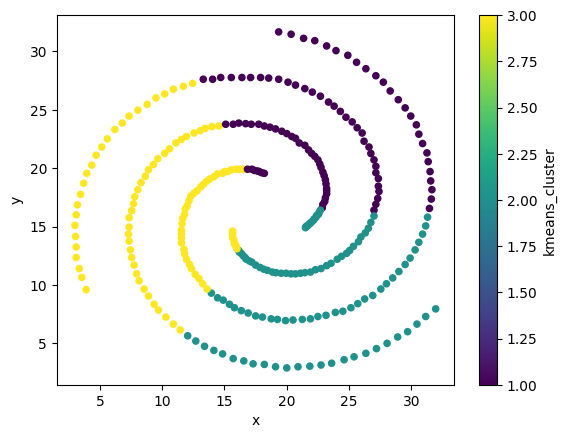

In [124]:
kmeans_df9.plot.scatter(x="x", y="y", c="kmeans_cluster", colormap='viridis')

-
-
-
-
-
-
-
-


(40 pts) Implement the Hierarchical clustering algorithm. And do the following:
• 3.a) Using the “single linkage” method, run the hierarchical clustering algorithm on the
dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report
SSE and RI.
• 3.b) Using the “complete linkage” method, run the hierarchical clustering algorithm on the
dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report
SSE and RI.
• 3.c) Using the “average linkage” method, run the hierarchical clustering algorithm on the
dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report
SSE and RI.
• 3.d) Using the “centroid linkage” method, run the hierarchical clustering algorithm on the
dataset, and get a 3-cluster result (by cutting the dendrogram at a certain height), and report
SSE and RI.
• 3.e) Please comment, out of the 4 clustering results (3.a), (3.b), (3.c) and (3.d) which
method gets you the best SSE as well as RI.
• 3.f) Please draw the clustering results (like Figure 1).
